## PROJECT 2: Activation Functions Comparison### 
Techniques: ReLU, Sigmoid, Tanh, LeakyReLU, ELU

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

In [2]:
print("Loading MNIST dataset...")
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 6s 1us/step


In [3]:
# Normalize
x_train = x_train.reshape(-1, 784).astype('float32') / 255
x_test = x_test.reshape(-1, 784).astype('float32') / 255

In [4]:
print(f"Training samples: {x_train.shape[0]}")
print(f"Test samples: {x_test.shape[0]}")

Training samples: 60000
Test samples: 10000


In [5]:
# Visualize activation functions
print("\nVisualizing activation functions...")
x = np.linspace(-5, 5, 100)


Visualizing activation functions...


In [6]:
activations = {
    'ReLU': tf.nn.relu(x),
    'Sigmoid': tf.nn.sigmoid(x),
    'Tanh': tf.nn.tanh(x),
    'LeakyReLU': tf.nn.leaky_relu(x, alpha=0.2),
    'ELU': tf.nn.elu(x)
}

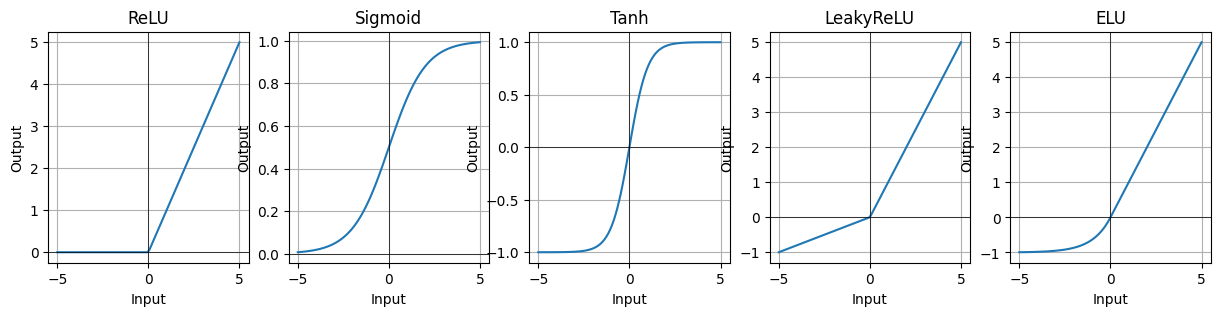

In [7]:
plt.figure(figsize=(15, 3))
for i, (name, activation) in enumerate(activations.items(), 1):
    plt.subplot(1, 5, i)
    plt.plot(x, activation)
    plt.title(name)
    plt.grid(True)
    plt.axhline(y=0, color='k', linewidth=0.5)
    plt.axvline(x=0, color='k', linewidth=0.5)
    plt.xlabel('Input')
    plt.ylabel('Output')

In [8]:
plt.tight_layout()
plt.savefig('activation_functions.png')
print("Activation functions plot saved as 'activation_functions.png'")

Activation functions plot saved as 'activation_functions.png'


<Figure size 640x480 with 0 Axes>

In [9]:
# Compare activation functions on MNIST
def create_model(activation):
    model = models.Sequential([
        layers.Dense(128, activation=activation, input_shape=(784,)),
        layers.Dense(64, activation=activation),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [10]:
print("\nComparing activation functions on MNIST classification...")
results = {}


Comparing activation functions on MNIST classification...


In [11]:
for activation in ['relu', 'sigmoid', 'tanh']:
    print(f"\nTraining with {activation}...")
    model = create_model(activation)
    
    history = model.fit(
        x_train[:5000], y_train[:5000],
        epochs=10,
        batch_size=128,
        validation_split=0.2,
        verbose=0
    )
    
    val_acc = history.history['val_accuracy'][-1]
    results[activation] = val_acc
    print(f"{activation}: Final Validation Accuracy = {val_acc:.4f}")


Training with relu...


C:\Users\Shridhar\tf_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


relu: Final Validation Accuracy = 0.9300

Training with sigmoid...
sigmoid: Final Validation Accuracy = 0.9030

Training with tanh...
tanh: Final Validation Accuracy = 0.9240


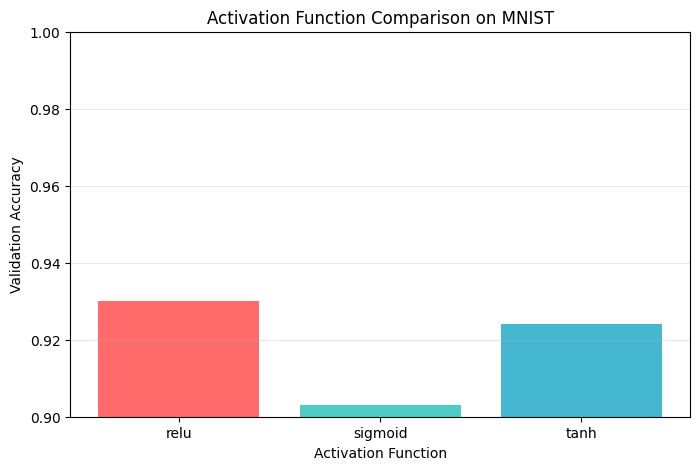

In [12]:
# Plot comparison
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.ylabel('Validation Accuracy')
plt.xlabel('Activation Function')
plt.title('Activation Function Comparison on MNIST')
plt.ylim([0.9, 1.0])
plt.grid(axis='y', alpha=0.3)

In [13]:
for name, value in results.items():
    plt.text(name, value + 0.005, f'{value:.4f}', ha='center')

Error in callback <function _draw_all_if_interactive at 0x000002160463E200> (for post_execute), with arguments args (),kwargs {}:


ConversionError: Failed to convert value(s) to axis units: 'relu'

ConversionError: Failed to convert value(s) to axis units: 'relu'

<Figure size 640x480 with 1 Axes>

In [14]:
plt.tight_layout()
plt.savefig('activation_comparison.png')
print("\nComparison plot saved as 'activation_comparison.png'")


Comparison plot saved as 'activation_comparison.png'


<Figure size 640x480 with 0 Axes>

In [15]:
print("\n✓ ReLU typically performs best for hidden layers")
print("✓ Sigmoid/Tanh can suffer from vanishing gradients")
print("✓ LeakyReLU/ELU help prevent dying ReLU problem")


✓ ReLU typically performs best for hidden layers
✓ Sigmoid/Tanh can suffer from vanishing gradients
✓ LeakyReLU/ELU help prevent dying ReLU problem
